See a indivsiual event

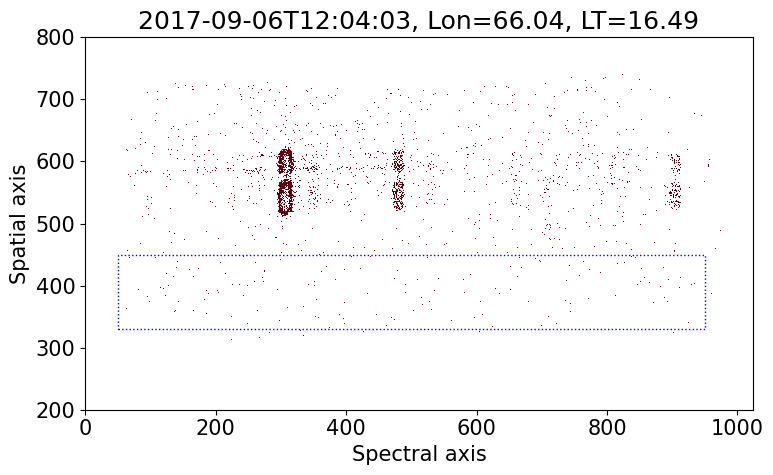

In [57]:
###Xray event ='2017-09-06T12:04:03'
import ipywidgets as widgets
import astropy.io.fits as iofits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from ipywidgets import interact, IntRangeSlider,interactive
from ipywidgets import Button, HBox, VBox
import matplotlib.patches as patches
plt.rcParams["font.size"] = 15

#Directory
dir_file = "/media/user/HDD-UT/Hisaki/euv/l2/"
dir_cal = "/media/user/HDD-UT/Hisaki/euv/cal/"

list_obs = iofits.open(dir_file+"exeuv.jupiter.mod.20.20170906.lv.02.vr.00.fits")
list_cal = iofits.open(dir_cal+"calib_20170906_v1.0.fits")

#separate header part and data part
pic = list_obs[306] #primary header
header = pic.header
data = pic.data

#x and y label
cal_x = list_cal[1].data #primary header
cal_y = list_cal[2].data
x1 = np.arange(1024)
y1 = np.arange(1024)

#plot contour image
data_masked = np.ma.masked_where(data <= 0, data)

cmap = plt.cm.viridis
cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=(8,5))

plt.pcolormesh(x1,y1,data_masked,vmin=0, vmax=1,cmap="Reds") 
cn = patches.Rectangle((50,330),950-50,450-330,lw=1.0,ec='b',linestyle='dotted',fill=False)
ax.add_patch(cn)
plt.ylim([200,800])
plt.title(str(header["DATE-OBS"])+", Lon="+str("{:.2f}".format(header["SLONESC"]))
          +", LT="+str("{:.2f}".format(header["LTESC"])))

plt.xlabel("Spectral axis")
plt.ylabel("Spatial axis")
plt.tight_layout()
plt.savefig("Image during X-ray event 2017.png",dpi=600)
plt.show()


平均値 (mean): 2.4250
中央値 (median): 2.0000


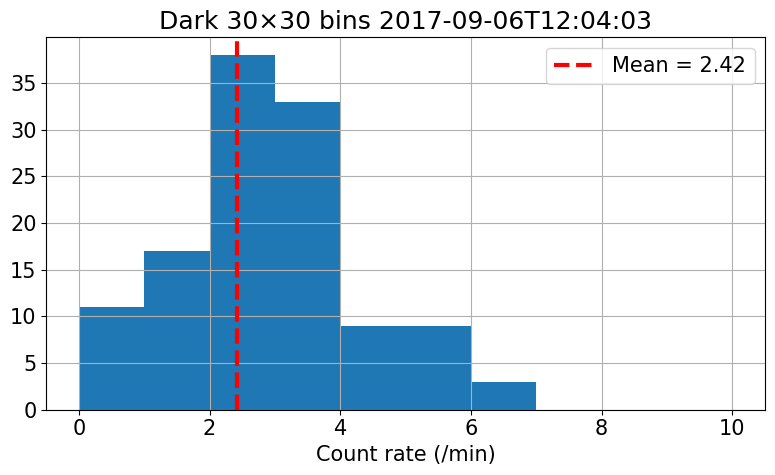

In [58]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 15

# 1. 5x5 binning fuction
def bin2d(array, bin_size=5, method='sum'):
    shape = (array.shape[0] // bin_size, bin_size,
             array.shape[1] // bin_size, bin_size)
    binned = array[:shape[0]*bin_size, :shape[2]*bin_size].reshape(shape)
    if method == 'sum':
        return binned.sum(axis=(1, 3))
    elif method == 'mean':
        return binned.mean(axis=(1, 3))

#show total counts of ROI
data1 = data[330:450,50:950] #y,x

# 2. Binning
data_binned = bin2d(data1, bin_size=30, method='sum')

# 3. Flatten
flattened = data_binned.flatten()

# 4. Calcualte mean and median
mean_val = np.mean(flattened)
median_val = np.median(flattened)

# 5. Show results
print(f"平均値 (mean): {mean_val:.4f}")
print(f"中央値 (median): {median_val:.4f}")

# 6. Visiualize histogram
plt.figure(figsize=(8, 5))
nmax = 10
plt.hist(flattened, bins=nmax, range=(0, nmax)) #np.max(flattened)))
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=3, label=f'Mean = {mean_val:.2f}')
#plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_val:.2f}')
plt.xlabel("Count rate (/min)")
#plt.ylabel("Count rate (/min)")
plt.title("Dark 30×30 bins "+str(header["DATE-OBS"]))
plt.legend()
#plt.ylim([0,200])
plt.grid(True)
plt.tight_layout()
plt.savefig("Histogram during X-ray event 2017.png",dpi=600)
plt.show()


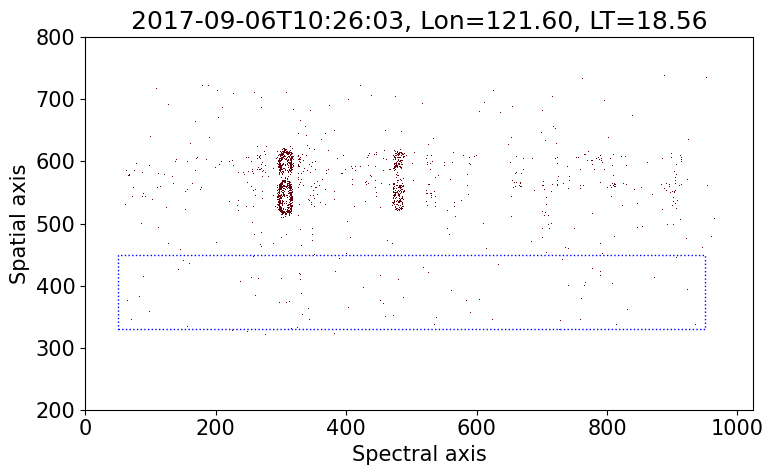

In [59]:
###Xray event ='2017-09-06T12:04:03'
import ipywidgets as widgets
import astropy.io.fits as iofits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from ipywidgets import interact, IntRangeSlider,interactive
from ipywidgets import Button, HBox, VBox
import matplotlib.patches as patches

plt.rcParams["font.size"] = 15

#Directory
dir_file = "/media/user/HDD-UT/Hisaki/euv/l2/"
dir_cal = "/media/user/HDD-UT/Hisaki/euv/cal/"

list_obs = iofits.open(dir_file+"exeuv.jupiter.mod.20.20170906.lv.02.vr.00.fits")
list_cal = iofits.open(dir_cal+"calib_20170906_v1.0.fits")

#separate header part and data part
pic = list_obs[285] #primary header
header = pic.header
data = pic.data

#x and y label
cal_x = list_cal[1].data #primary header
cal_y = list_cal[2].data
x1 = np.arange(1024)
y1 = np.arange(1024)

#plot contour image

data_masked = np.ma.masked_where(data <= 0, data)

cmap = plt.cm.viridis
cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=(8,5))
plt.pcolormesh(x1,y1,data_masked,vmin=0, vmax=1,cmap="Reds") 
cn = patches.Rectangle((50,330),950-50,450-330,lw=1.0,ec='b',linestyle='dotted',fill=False)
ax.add_patch(cn)
plt.ylim([200,800])
plt.title(str(header["DATE-OBS"])+", Lon="+str("{:.2f}".format(header["SLONESC"]))
          +", LT="+str("{:.2f}".format(header["LTESC"])))
plt.xlabel("Spectral axis")
plt.ylabel("Spatial axis")
#plt.pcolormesh(cal_x[512,:],cal_y[:,512],data,norm=colors.LogNorm(vmin=1e-1,vmax=1e3)) 
#plt.colorbar()
plt.tight_layout()
plt.savefig("Image before X-ray event 2017.png",dpi=600)
plt.show()


平均値 (mean): 1.3750
中央値 (median): 1.0000


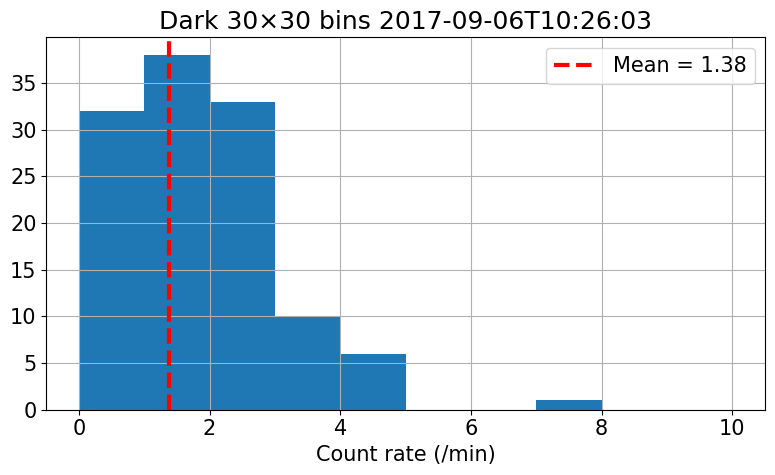

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 15

# 1. 5x5 bining function
def bin2d(array, bin_size=5, method='sum'):
    shape = (array.shape[0] // bin_size, bin_size,
             array.shape[1] // bin_size, bin_size)
    binned = array[:shape[0]*bin_size, :shape[2]*bin_size].reshape(shape)
    if method == 'sum':
        return binned.sum(axis=(1, 3))
    elif method == 'mean':
        return binned.mean(axis=(1, 3))

#show total counts of ROI
data1 = data[330:450,50:950] #y,x

# 2. Bining
data_binned = bin2d(data1, bin_size=30, method='sum')

# 3. Flatten
flattened = data_binned.flatten()

# 4. Calculate mean and median
mean_val = np.mean(flattened)
median_val = np.median(flattened)

# 5. Show results
print(f"平均値 (mean): {mean_val:.4f}")
print(f"中央値 (median): {median_val:.4f}")

# 6. Visualize histogram
plt.figure(figsize=(8, 5))
nmax = 10
plt.hist(flattened, bins=nmax, range=(0, nmax)) #np.max(flattened)))
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=3, label=f'Mean = {mean_val:.2f}')
#plt.axvline(median_val, color='green', linestyle='dashed', linewidth=1, label=f'Median = {median_val:.2f}')
plt.xlabel("Count rate (/min)")
#plt.ylabel("Count rate (/min)")
plt.title("Dark 30×30 bins "+str(header["DATE-OBS"]))
plt.legend()
#plt.ylim([0,200])
plt.grid(True)
plt.tight_layout()
plt.savefig("Histogram before X-ray event 2017.png",dpi=600)
plt.show()
